In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Human TF promoter-level chec-seq binding signal
sumprom_chec_glob = "sumproms/*.gz"

# Extracted footprint directory (see analysis code for calculation)
footprint_dir = "../Experimental_data_analysis/fimo_footprints/hocomoco_1e3_pthreshold/representative_hoco_motif/raw_signals"

## Imports

In [3]:
import glob
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

## Data Loading

In [4]:
supmrom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in supmrom_chec_files], axis=1)

FOXK1_WT = ["FOXP3","FOXA2","FOXF1","FOXL1","FOXL2","FOXJ2","FOXO3","FOXP1","FOXP2"]
GABPA_WT = ["ELF1","ELF2","ERF1","ELK1","ELK4","ERG","FLI1"]
SOX10_WT = ["SOX15","SOX17","SOX7","SOX11","SOX4","SOX6","SOX30","SOX9","SOX13","SOX5"]
HXD10_WT = ["CDX2","HOXA11","HOXC10","HOXD9","HOXA10","HOXC9","HOXA9","HOXB9","CDX4","HOXC13"]
GATA1_WT = ["GATA3","GATA6","GATA4","GATA2","GATA5"]
BATF3_WT = ["ATF4","FOS","CREB5","ATF1","CREB1","ATF2"]
HEY1_WT = ["MNT","MLXIPL","MLX","MXD4"]
NFAC4_WT = ["NFATC4","NFATC3"]
TF2LY_WT = ["TGIF2LX","TGIF2LY","TGIF1","TGIF2"]
PO3F2_WT = ["POU2F3","POU3F4","POU3F1"]

dbd_fam_dict = {"FOXK1_WT": FOXK1_WT, "GABPA_WT": GABPA_WT, "SOX10_WT": SOX10_WT, "HXD10_WT": HXD10_WT, "GATA1_WT": GATA1_WT, "BATF3_WT": BATF3_WT, "HEY1_WT": HEY1_WT, "NFAC4_WT": NFAC4_WT, "TF2LY_WT": TF2LY_WT, "PO3F2_WT": PO3F2_WT}

wt_tfs = {tf for fam in dbd_fam_dict.values() for tf in fam}
sumprom_all = sumprom_all[[c for c in sumprom_all.columns if (m := re.match(r'^([^_]+)_([0-9])', c)) and m.group(1) in wt_tfs]]

## Data Processing

In [5]:
z_threshold = 3
z = (sumprom_all - sumprom_all.mean()) / sumprom_all.std()
sum_raw_top_z = sumprom_all.where(z > z_threshold).sum().to_dict()
sum_raw_top_z_log = {k: np.log2(v) for k, v in sum_raw_top_z.items()}

## Helper Functions

In [6]:
footprint_dir = Path(footprint_dir)
flank_for_rank = 25
top_n_motifs = 200
plot_x_lim = 150

reps_to_plot = [
    "SOX5",
    "SOX6",
    "SOX13",
    "SOX17"
]

In [7]:
# Options for smoothing the footprint
smooth         = True
smooth_method  = "mean"
smooth_window  = 5

In [8]:
# Compute the footprint profile for a dataframe
def compute_profile(df):
    pos_cols = sorted(
        [c for c in df.columns if c.startswith("pos_")],
        key=lambda x: int(x.replace("pos_", ""))
    )

    rank_cols = [f"pos_{i}" for i in range(-flank_for_rank, flank_for_rank + 1)]
    df = df.copy()
    df["rank_score"] = df[rank_cols].sum(axis=1)

    df = df.sort_values("rank_score", ascending=False).head(top_n_motifs)

    y = df[pos_cols].mean(axis=0).values

    if smooth:
        if smooth_method == "mean":
            kernel = np.ones(smooth_window) / smooth_window
            y = np.convolve(y, kernel, mode="same")
        elif smooth_method == "median":
            y = pd.Series(y).rolling(smooth_window, center=True, min_periods=1).median().values

    pos_bp = np.array([int(c.replace("pos_", "")) for c in pos_cols])

    return pd.DataFrame({"pos_bp": pos_bp, "y": y})

## Plotting

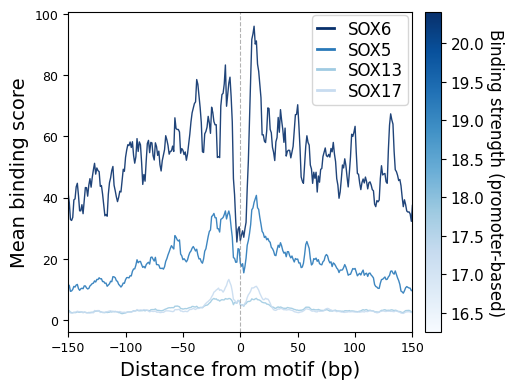

In [9]:
# Plot footprint profiles colored by binding strength
sample_score = {
    s: np.mean([v for k, v in sum_raw_top_z_log.items() if k.startswith(f"{s}_")])
    for s in reps_to_plot
}

cmap = cm.Blues
vals = list(sample_score.values())
norm = colors.Normalize(vmin=min(vals)-1, vmax=max(vals))

plt.figure(figsize=(5.2, 4))

for s in reps_to_plot:
    prof = compute_profile(pd.read_csv(footprint_dir / f"{s}_raw_windows.csv"))
    plt.plot(prof["pos_bp"], prof["y"],
             color=cmap(norm(sample_score[s])),
             alpha=0.9, lw=1)

plt.axvline(0, linestyle="--", color="grey", lw=0.8, alpha=0.6)
plt.xlim(-plot_x_lim, plot_x_lim)
plt.xlabel("Distance from motif (bp)", fontsize=14)
plt.ylabel("Mean binding score", fontsize=14)
plt.tick_params(axis="both", labelsize=9)
plt.tight_layout()

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.03)
cbar.set_label("Binding strength (promoter-based)",
               rotation=270, labelpad=14, fontsize=12)
cbar.ax.tick_params(labelsize=11)

for s in sorted(reps_to_plot, key=lambda x: sample_score[x], reverse=True):
    plt.plot([], [], color=cmap(norm(sample_score[s])), lw=2, label=s)

plt.legend(loc="upper right",
           bbox_to_anchor=(1.01, 1.015),
           fontsize=12,
           title_fontsize=14,
           handlelength=1,
           labelspacing=0.15,
           frameon=True, borderpad=0.3)

plt.show()